<a href="https://colab.research.google.com/github/rodrigogossi/ic_rodrigogossi_yollov8/blob/main/calculo_de_area_v2_640px.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cálculo de Área de Crescimento Fúngico — YOLOv8 Segmentação
Comparação com gabarito do ImageJ
Ambiente: Google Colab

CÉLULA 1 — Instalação

In [1]:
!pip install -U ultralytics opencv-python-headless pandas numpy matplotlib scipy scikit-learn

CÉLULA 2 — Imports

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import r2_score, mean_squared_error

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


CÉLULA 3 — Configurações  ← EDITE AQUI

In [3]:
# Montar o Drive antes:
from google.colab import drive
drive.mount("/content/drive")

# Modelo treinado — use o best.pt do fold com maior mAP50
# Dica: verifique o CSV metricas_completas.csv para identificar o melhor fold
MODELO_PATH = "/content/drive/MyDrive/ic-yollov8/resultados_640px_2026-03-18/runs/rep2_fold5/weights/best.pt"

# Pasta com as imagens a avaliar (pode ser todo o dataset ou só as de val)
PASTA_IMAGENS = "/content/drive/MyDrive/ic-yollov8/dataset_bruto/images"

# CSV do gabarito exportado do ImageJ
# Colunas esperadas: 'identificador' e 'Area(mm²)'
ARQUIVO_GABARITO = "/content/drive/MyDrive/ic-yollov8/gabarito.csv"

# Pasta onde os resultados serão salvos
PASTA_SAIDA = Path("/content/drive/MyDrive/ic-yollov8/resultados_area_640")
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

# Configuração da escala física
# Meça o lado do quadrado de papel que aparece nas fotos
LADO_ESCALA_CM    = 4.0
AREA_ESCALA_MM2   = (LADO_ESCALA_CM * 10) ** 2  # 1600 mm²

# Parâmetros de inferência
IMGSZ                    = 640     # deve bater com a resolução do treino
CONF                     = 0.20
IOU                      = 0.60
LIMITE_MIN_PX_ESCALA     = 1000   # ignora detecções de escala muito pequenas (ruído)

# IDs das classes — devem bater com seu data.yaml
ID_CLASSE_ESCALA = 0
ID_CLASSE_FUNGO  = 1


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CÉLULA 4 — Funções auxiliares

In [4]:

def carregar_gabarito(caminho_csv):
    """Lê o CSV do ImageJ e retorna dicionário {nome_imagem: area_real_mm2}."""
    print(f"📂 Lendo gabarito: {caminho_csv}")
    try:
        df = pd.read_csv(caminho_csv, sep=None, engine='python')

        # Mostra colunas encontradas para diagnóstico
        print(f"   Colunas encontradas: {list(df.columns)}")

        col_id   = 'identificador'
        col_area = 'Area(mm²)'

        gabarito = {}
        for _, row in df.iterrows():
            nome     = str(row[col_id]).strip().rsplit('.', 1)[0]
            area_str = str(row[col_area]).replace(',', '.')
            gabarito[nome] = float(area_str)

        print(f"✅ Gabarito carregado: {len(gabarito)} amostras")
        return gabarito
    except Exception as e:
        print(f"❌ Erro ao ler CSV: {e}")
        print("   Verifique os nomes das colunas acima e ajuste col_id e col_area se necessário")
        return None


def processar_mascaras(resultado_yolo):
    """
    Extrai áreas em pixels da escala e do fungo.
    - Escala: pega a maior detecção (ignora ruído)
    - Fungo:  soma todas as colônias detectadas
    Retorna (px_escala, px_fungo, n_colonias)
    """
    area_px_escala = 0.0
    area_px_fungo  = 0.0
    n_colonias     = 0

    if resultado_yolo.masks is None:
        return 0.0, 0.0, 0

    for i, class_id in enumerate(resultado_yolo.boxes.cls):
        mascara = resultado_yolo.masks.xy[i]
        if len(mascara) == 0:
            continue

        area_px = cv2.contourArea(mascara.astype(np.float32))
        classe  = int(class_id)

        if classe == ID_CLASSE_ESCALA:
            if area_px > area_px_escala:
                area_px_escala = area_px

        elif classe == ID_CLASSE_FUNGO:
            area_px_fungo += area_px
            n_colonias    += 1

    return area_px_escala, area_px_fungo, n_colonias


def calcular_ic_bootstrap(real, predito, n_boot=1000, ci=95):
    """
    Calcula intervalo de confiança por bootstrap para R², RMSE e MAPE.
    Retorna dicionário com mean e (low, high) de cada métrica.
    """
    rng = np.random.default_rng(42)
    r2_boot, rmse_boot, mape_boot = [], [], []

    for _ in range(n_boot):
        idx    = rng.integers(0, len(real), len(real))
        r_s    = real[idx]
        p_s    = predito[idx]
        r2_boot.append(r2_score(r_s, p_s))
        rmse_boot.append(np.sqrt(mean_squared_error(r_s, p_s)))
        mape_boot.append(np.mean(np.abs((r_s - p_s) / np.where(r_s > 0, r_s, 1)) * 100))

    alpha = (100 - ci) / 2
    return {
        'R2'  : (np.mean(r2_boot),   np.percentile(r2_boot,   alpha), np.percentile(r2_boot,   100-alpha)),
        'RMSE': (np.mean(rmse_boot), np.percentile(rmse_boot, alpha), np.percentile(rmse_boot, 100-alpha)),
        'MAPE': (np.mean(mape_boot), np.percentile(mape_boot, alpha), np.percentile(mape_boot, 100-alpha)),
    }

CÉLULA 5 — Inferência e cálculo de área

In [5]:

gabarito = carregar_gabarito(ARQUIVO_GABARITO)
if gabarito is None:
    raise SystemExit("Corrija o CSV do gabarito antes de continuar.")

print(f"\n🚀 Carregando modelo: {MODELO_PATH}")
model   = YOLO(MODELO_PATH)
imagens = sorted(Path(PASTA_IMAGENS).glob('*.[jp][pn]g'))
print(f"📸 Imagens encontradas: {len(imagens)}")

resultados      = []
sem_gabarito    = []
sem_escala      = []
sem_fungo       = []

print(f"\n{'ARQUIVO':<35} {'REAL':>10} {'IA':>10} {'ERRO%':>8} {'COLÔNIAS':>9}")
print("─" * 75)

for img_path in imagens:
    nome = img_path.stem

    if nome not in gabarito:
        sem_gabarito.append(nome)
        continue

    area_real = gabarito[nome]

    # Inferência
    resultado = model(
        str(img_path),
        verbose      = False,
        imgsz        = IMGSZ,
        conf         = CONF,
        iou          = IOU,
        retina_masks = True,   # máscaras na resolução nativa — essencial
    )[0]

    px_escala, px_fungo, n_col = processar_mascaras(resultado)

    # Filtro de escala inválida
    if px_escala < LIMITE_MIN_PX_ESCALA:
        sem_escala.append(nome)
        continue

    # Conversão pixels → mm²
    fator      = AREA_ESCALA_MM2 / px_escala
    area_ia    = px_fungo * fator

    # Métricas de erro
    erro_abs   = abs(area_ia - area_real)
    erro_perc  = (erro_abs / area_real * 100) if area_real > 0 else 0.0

    if px_fungo == 0:
        sem_fungo.append(nome)

    print(f"{nome:<35} {area_real:>10.2f} {area_ia:>10.2f} {erro_perc:>8.2f} {n_col:>9}")

    resultados.append({
        'Arquivo'      : nome,
        'Real_mm2'     : area_real,
        'IA_mm2'       : area_ia,
        'Erro_Abs_mm2' : erro_abs,
        'Erro_Perc'    : erro_perc,
        'N_Colonias'   : n_col,
        'Px_Escala'    : px_escala,
        'Fator_Conv'   : round(fator, 6),
    })

print("─" * 75)
print(f"\n⚠️  Sem gabarito   : {len(sem_gabarito)} imagens ignoradas")
print(f"⚠️  Sem escala válida: {len(sem_escala)} imagens ignoradas")
print(f"⚠️  Sem fungo detectado: {len(sem_fungo)} imagens (área = 0)")



📂 Lendo gabarito: /content/drive/MyDrive/ic-yollov8/gabarito.csv
   Colunas encontradas: ['identificador', 'Area(mm²)']
✅ Gabarito carregado: 542 amostras

🚀 Carregando modelo: /content/drive/MyDrive/ic-yollov8/resultados_640px_2026-03-18/runs/rep2_fold5/weights/best.pt
📸 Imagens encontradas: 542

ARQUIVO                                   REAL         IA    ERRO%  COLÔNIAS
───────────────────────────────────────────────────────────────────────────
d1_t2_100uL_r1                           66.53      70.76     6.36         1
d1_t2_100uL_r2                           63.46      71.58    12.79         1
d1_t2_100uL_r3                           77.34      81.46     5.32         1
d1_t2_100uL_r3B                         135.95     136.25     0.22         1
d1_t2_100uL_r4                           84.49      87.99     4.15         1
d1_t2_100uL_r5                           70.06      72.95     4.12         1
d1_t2_20uL_r1                           177.10      89.84    49.27         1
d1_t2_20u

CÉLULA 6 — Métricas estatísticas com intervalo de confiança

In [6]:

if not resultados:
    raise SystemExit("⚠️ Nenhuma imagem processada. Verifique caminhos e nomes.")

df = pd.DataFrame(resultados)

real    = df['Real_mm2'].values
predito = df['IA_mm2'].values

r2   = r2_score(real, predito)
rmse = np.sqrt(mean_squared_error(real, predito))
mae  = np.mean(df['Erro_Abs_mm2'])
mape = df['Erro_Perc'].mean()

# Intervalo de confiança por bootstrap (95%)
ic = calcular_ic_bootstrap(real, predito)

# Teste de correlação de Pearson
pearson_r, pearson_p = stats.pearsonr(real, predito)

print("\n" + "="*55)
print("  MÉTRICAS FINAIS COM INTERVALO DE CONFIANÇA (95%)")
print("="*55)
print(f"  Amostras validadas : {len(df)}")
print(f"  R²     : {r2:.4f}  [{ic['R2'][1]:.4f} – {ic['R2'][2]:.4f}]")
print(f"  RMSE   : {rmse:.2f} mm²  [{ic['RMSE'][1]:.2f} – {ic['RMSE'][2]:.2f}]")
print(f"  MAE    : {mae:.2f} mm²")
print(f"  MAPE   : {mape:.2f}%  [{ic['MAPE'][1]:.2f}% – {ic['MAPE'][2]:.2f}%]")
print(f"  Pearson r = {pearson_r:.4f}  (p = {pearson_p:.2e})")
print("="*55)



  MÉTRICAS FINAIS COM INTERVALO DE CONFIANÇA (95%)
  Amostras validadas : 542
  R²     : 0.9984  [0.9979 – 0.9988]
  RMSE   : 60.85 mm²  [51.95 – 70.18]
  MAE    : 34.63 mm²
  MAPE   : 6.97%  [6.03% – 8.11%]
  Pearson r = 0.9992  (p = 0.00e+00)


CÉLULA 7 — Gráficos para o artigo

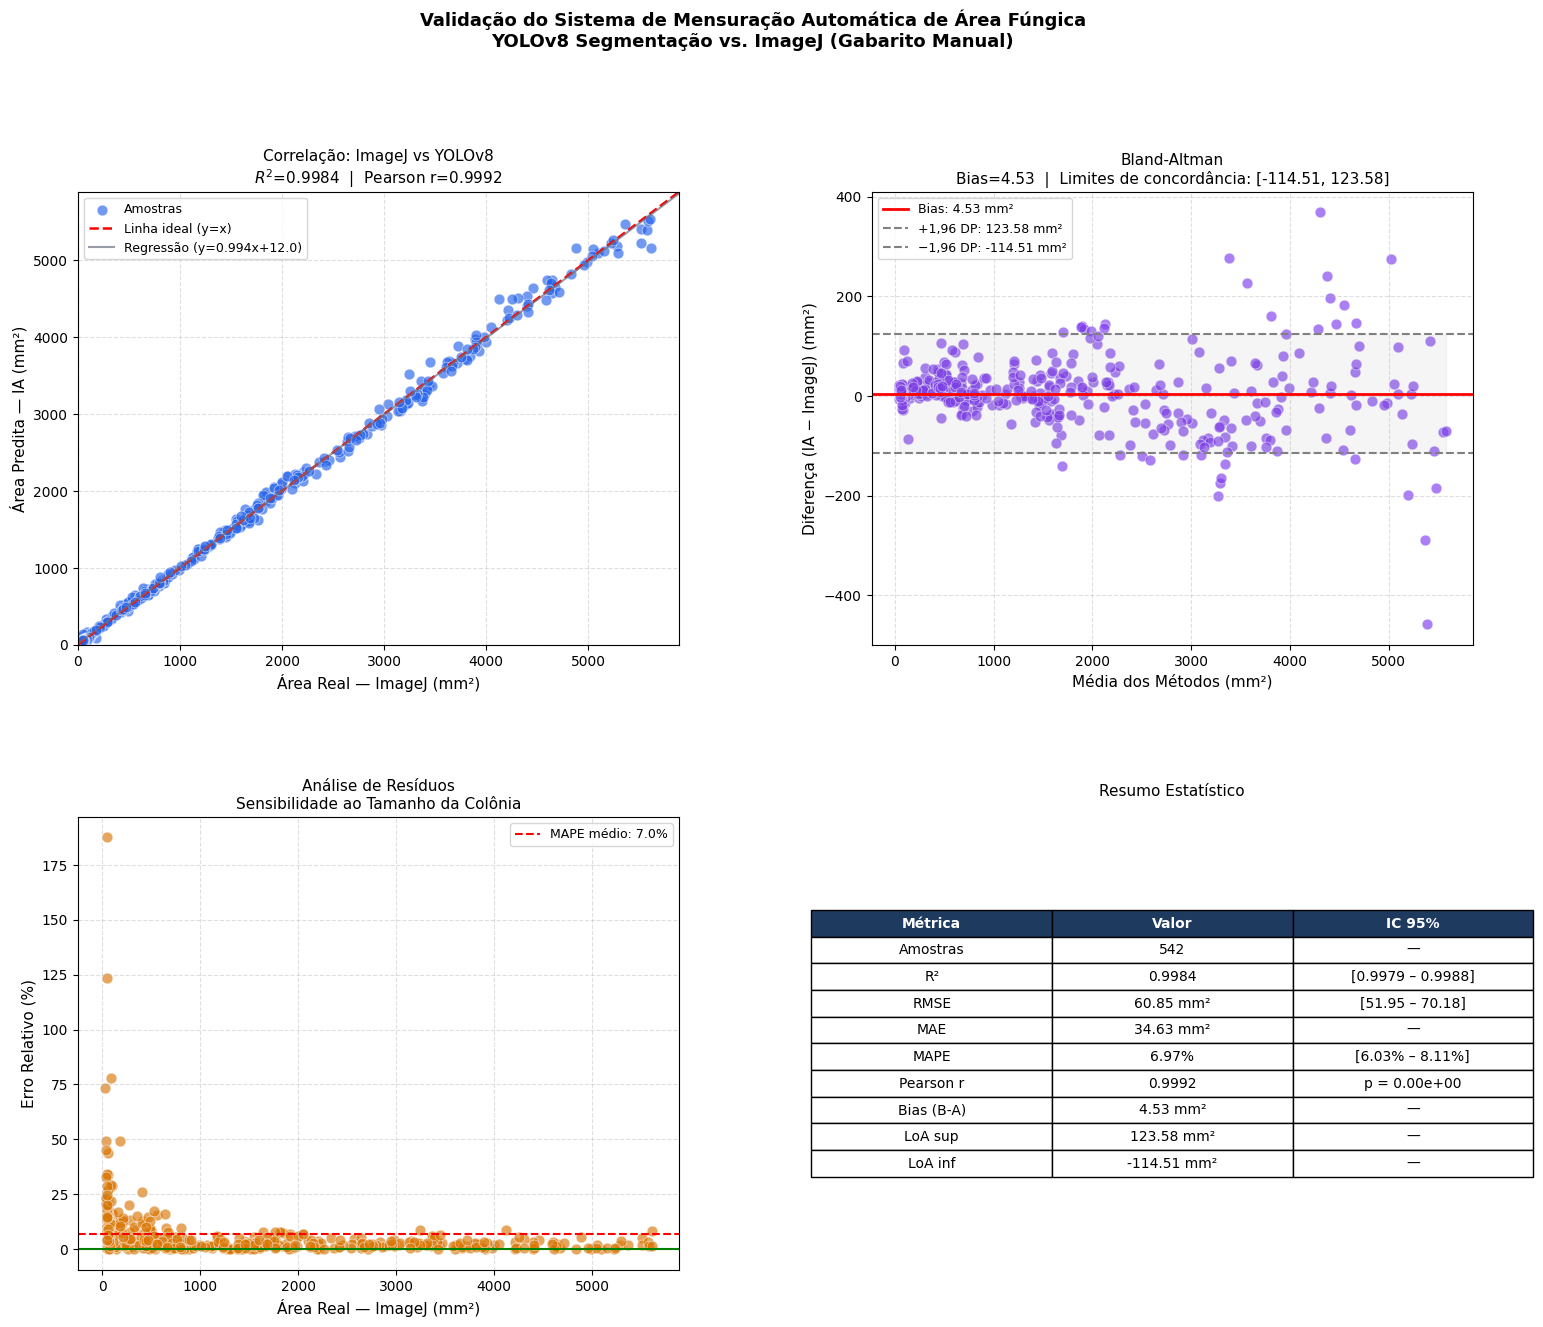

✅ Gráfico salvo: /content/drive/MyDrive/ic-yollov8/resultados_area_640/validacao_area_fungica.png


In [7]:

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

AZUL    = "#2563EB"
ROXO    = "#7C3AED"
CINZA   = "#6B7280"

# ── Gráfico 1: Dispersão Real vs IA ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(real, predito, alpha=0.65, color=AZUL, edgecolors='white',
            linewidths=0.5, s=60, label='Amostras')

lim = max(real.max(), predito.max()) * 1.05
ax1.plot([0, lim], [0, lim], 'r--', linewidth=1.8, label='Linha ideal (y=x)')

# Linha de regressão
m, b     = np.polyfit(real, predito, 1)
x_reg    = np.linspace(0, lim, 100)
ax1.plot(x_reg, m * x_reg + b, color=CINZA, linewidth=1.5,
         linestyle='-', alpha=0.7, label=f'Regressão (y={m:.3f}x+{b:.1f})')

ax1.set_xlim(0, lim)
ax1.set_ylim(0, lim)
ax1.set_xlabel('Área Real — ImageJ (mm²)', fontsize=11)
ax1.set_ylabel('Área Predita — IA (mm²)', fontsize=11)
ax1.set_title(f'Correlação: ImageJ vs YOLOv8\n$R^2$={r2:.4f}  |  Pearson r={pearson_r:.4f}', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Gráfico 2: Bland-Altman ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

media_metodos = (real + predito) / 2
diferenca     = predito - real
bias          = np.mean(diferenca)
sd            = np.std(diferenca, ddof=1)
loa_sup       = bias + 1.96 * sd
loa_inf       = bias - 1.96 * sd

ax2.scatter(media_metodos, diferenca, alpha=0.65, color=ROXO,
            edgecolors='white', linewidths=0.5, s=60)
ax2.axhline(bias,    color='red',   linestyle='-',  linewidth=2.0,
            label=f'Bias: {bias:.2f} mm²')
ax2.axhline(loa_sup, color='gray',  linestyle='--', linewidth=1.5,
            label=f'+1,96 DP: {loa_sup:.2f} mm²')
ax2.axhline(loa_inf, color='gray',  linestyle='--', linewidth=1.5,
            label=f'−1,96 DP: {loa_inf:.2f} mm²')

# Faixa de concordância sombreada
ax2.fill_between(
    [media_metodos.min(), media_metodos.max()],
    loa_inf, loa_sup, alpha=0.08, color='gray'
)

ax2.set_xlabel('Média dos Métodos (mm²)', fontsize=11)
ax2.set_ylabel('Diferença (IA − ImageJ) (mm²)', fontsize=11)
ax2.set_title(
    f'Bland-Altman\nBias={bias:.2f}  |  Limites de concordância: [{loa_inf:.2f}, {loa_sup:.2f}]',
    fontsize=11
)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

# ── Gráfico 3: Resíduos por tamanho ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(real, df['Erro_Perc'], alpha=0.65, color='#D97706',
            edgecolors='white', linewidths=0.5, s=60)
ax3.axhline(0,    color='green', linestyle='-',  linewidth=1.5)
ax3.axhline(mape, color='red',   linestyle='--', linewidth=1.5,
            label=f'MAPE médio: {mape:.1f}%')

ax3.set_xlabel('Área Real — ImageJ (mm²)', fontsize=11)
ax3.set_ylabel('Erro Relativo (%)', fontsize=11)
ax3.set_title('Análise de Resíduos\nSensibilidade ao Tamanho da Colônia', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.4)

# ── Gráfico 4: Tabela de métricas ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

tabela_dados = [
    ['Métrica',  'Valor',   'IC 95%'],
    ['Amostras', f'{len(df)}', '—'],
    ['R²',       f'{r2:.4f}',  f'[{ic["R2"][1]:.4f} – {ic["R2"][2]:.4f}]'],
    ['RMSE',     f'{rmse:.2f} mm²', f'[{ic["RMSE"][1]:.2f} – {ic["RMSE"][2]:.2f}]'],
    ['MAE',      f'{mae:.2f} mm²',  '—'],
    ['MAPE',     f'{mape:.2f}%',    f'[{ic["MAPE"][1]:.2f}% – {ic["MAPE"][2]:.2f}%]'],
    ['Pearson r', f'{pearson_r:.4f}', f'p = {pearson_p:.2e}'],
    ['Bias (B-A)', f'{bias:.2f} mm²', '—'],
    ['LoA sup',  f'{loa_sup:.2f} mm²', '—'],
    ['LoA inf',  f'{loa_inf:.2f} mm²', '—'],
]

tabela = ax4.table(
    cellText  = tabela_dados[1:],
    colLabels = tabela_dados[0],
    loc       = 'center',
    cellLoc   = 'center',
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)

# Cabeçalho em negrito
for j in range(3):
    tabela[0, j].set_facecolor('#1E3A5F')
    tabela[0, j].set_text_props(color='white', fontweight='bold')

ax4.set_title('Resumo Estatístico', fontsize=11, pad=15)

# ── Salvar ───────────────────────────────────────────────────────────────────
fig.suptitle(
    'Validação do Sistema de Mensuração Automática de Área Fúngica\nYOLOv8 Segmentação vs. ImageJ (Gabarito Manual)',
    fontsize=13, fontweight='bold', y=1.01
)

grafico_path = PASTA_SAIDA / "validacao_area_fungica.png"
plt.savefig(grafico_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Gráfico salvo: {grafico_path}")


CÉLULA 8 — Salvar relatório CSV e resumo no Drive

In [8]:

# CSV detalhado por imagem
csv_path = PASTA_SAIDA / "relatorio_validacao_area.csv"
df.to_csv(csv_path, index=False)
print(f"✅ Relatório CSV salvo: {csv_path}")

# Resumo estatístico em CSV separado (útil para copiar para o artigo)
resumo = pd.DataFrame([{
    'N_amostras'     : len(df),
    'R2'             : round(r2, 4),
    'R2_IC_low'      : round(ic['R2'][1], 4),
    'R2_IC_high'     : round(ic['R2'][2], 4),
    'RMSE_mm2'       : round(rmse, 2),
    'RMSE_IC_low'    : round(ic['RMSE'][1], 2),
    'RMSE_IC_high'   : round(ic['RMSE'][2], 2),
    'MAE_mm2'        : round(mae, 2),
    'MAPE_pct'       : round(mape, 2),
    'MAPE_IC_low'    : round(ic['MAPE'][1], 2),
    'MAPE_IC_high'   : round(ic['MAPE'][2], 2),
    'Pearson_r'      : round(pearson_r, 4),
    'Pearson_p'      : f'{pearson_p:.2e}',
    'BlandAltman_bias'   : round(bias, 2),
    'BlandAltman_LoA_sup': round(loa_sup, 2),
    'BlandAltman_LoA_inf': round(loa_inf, 2),
    'Modelo'         : MODELO_PATH,
    'IMGSZ'          : IMGSZ,
    'CONF'           : CONF,
}])

resumo_path = PASTA_SAIDA / "resumo_estatistico.csv"
resumo.to_csv(resumo_path, index=False)
print(f"✅ Resumo estatístico salvo: {resumo_path}")

print("\n" + "="*55)
print("  CONCLUÍDO — Arquivos salvos no Drive:")
print("="*55)
print(f"  📊 {grafico_path.name}")
print(f"  📄 {csv_path.name}")
print(f"  📄 {resumo_path.name}")


✅ Relatório CSV salvo: /content/drive/MyDrive/ic-yollov8/resultados_area_640/relatorio_validacao_area.csv
✅ Resumo estatístico salvo: /content/drive/MyDrive/ic-yollov8/resultados_area_640/resumo_estatistico.csv

  CONCLUÍDO — Arquivos salvos no Drive:
  📊 validacao_area_fungica.png
  📄 relatorio_validacao_area.csv
  📄 resumo_estatistico.csv
